# Parameter estimation with `cogwheel`

In this exercise we will learn to:

* Estimate the chirp mass of a signal from its frequency evolution
* Use the software `cogwheel` to:
    - Generate a synthetic event ("injection") in Gaussian noise
    - Plot whitened data as a spectrogram or time series
    - Find a good-fit waveform
    - Sample the posterior distribution using nested sampling
    - Corner-plot the posterior distribution

For reference, here are `cogwheel`'s [documentation](https://cogwheel.readthedocs.io/en/latest/index.html) and [source code (GitHub)](https://github.com/jroulet/cogwheel). You can find additional tutorials in the GitHub repository.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils

import lal

%matplotlib widget

# Only needed on Apple M4 with numpy<2.3 https://github.com/numpy/numpy/issues/28687
# (still, ok on other systems)
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

/Users/abbywilliams/Research/venv/gwaves/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Simulate a new detected event

To simulate a detection where we don't know the parameters in advance, we will generate source parameters randomly, generate the associated signal and inject it on Gaussian noise colored according to example LIGO-Virgo PSDs.

This is done in the cell below (it's not super important to follow every step).

In [2]:
def _generate_injection_dic(seed):
    aux_prior = cogwheel.gw_prior.IASPrior(
        f_ref=100.0,
        mchirp_range=(10, 50),
        detector_pair='HL',
        tgps=0,
        ref_det_name='H',
        f_avg=100.0,
        d_hat_max=100.0,
        dt0=10,
    )
    injection_dic = dict(
        aux_prior.generate_random_samples(1, seed=seed).loc[0, aux_prior.standard_params])
    return injection_dic


def get_event_data(seed=0):
    """Return an EventData with a secret injection in it."""
    injection_dic = _generate_injection_dic(seed)

    asd_funcs = list(cogwheel.data.ASDS)

    eventname = f'GW{seed}'
    event_data = cogwheel.data.EventData.gaussian_noise(
        eventname, duration=128.0, detector_names='HLV', fmax=512.0,
        asd_funcs=asd_funcs, tgps=0.0, seed=seed)

    event_data.inject_signal(par_dic=injection_dic, approximant='IMRPhenomXODE')

    return event_data


event_data = get_event_data(seed=0)

Let's plot a spectrogram of the whitened data:

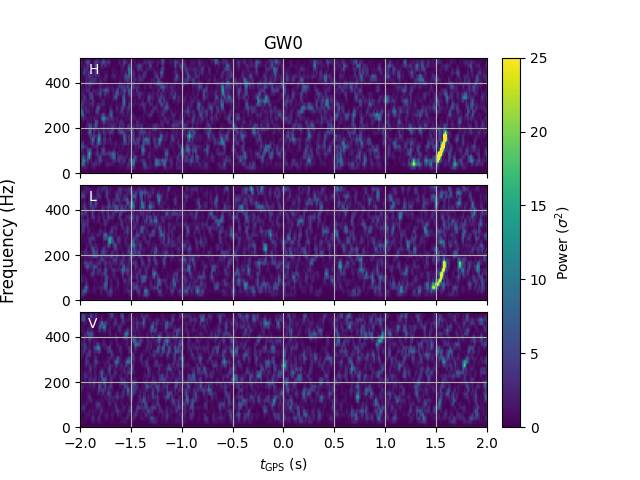

In [3]:
xlim = (-2, 2)  # Edit this
event_data.specgram(xlim=xlim);

A spectrogram is a time-frequency representation of the data.
The horizontal axis is time, the vertical axis frequency, and the color power.
You can think of the columns of a spectrogram as short-time PSDs.
The panels of the plot show different detectors.

* Find the event, estimate the merger time (hint: adjust `xlim` to best display the event)

In [4]:
t_merger_guess = 1.6

`cogwheel` uses an algorithm called relative-binning to speed up likelihood computations.
This method requires a reference waveform that is a good fit to the signal.
We will obtain this well-fitting waveform by maximizing the likelihood, but this requires an initial guess for the mass.

Can we guess the mass of the signal by inspecting the data?
Recall that the time to merger depends on the chirp-mass and the frequency as
$$
    f^{-8/3} = \frac{(8\pi)^{8/3}}{5} \left(\frac{G \mathcal{M}}{c^3}\right)^{5/3} (t_\mathrm{merger} - t)
$$

* Which stays longer in the detector frequency band: a heavy or a light signal?
* From the spectrogram, estimate the time to merger as a function of frequency and from there guess the (detector frame, i.e. redshifted) chirp mass.

Another plot we can do is that of the whitened data:

In [5]:
whitened_td = event_data.get_whitened_td()

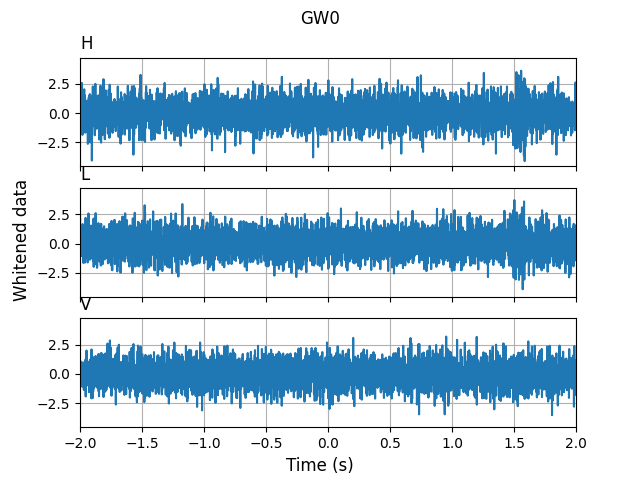

In [6]:
fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for det_name, ax, wht_strain in zip(event_data.detector_names, axs, whitened_td):
    ax.plot(event_data.times - event_data.tcoarse, wht_strain)
    ax.grid()
    ax.set_title(det_name, loc='left')

ax.set_xlim(xlim)
fig.supxlabel('Time (s)')
fig.supylabel('Whitened data')
fig.suptitle(event_data.eventname);

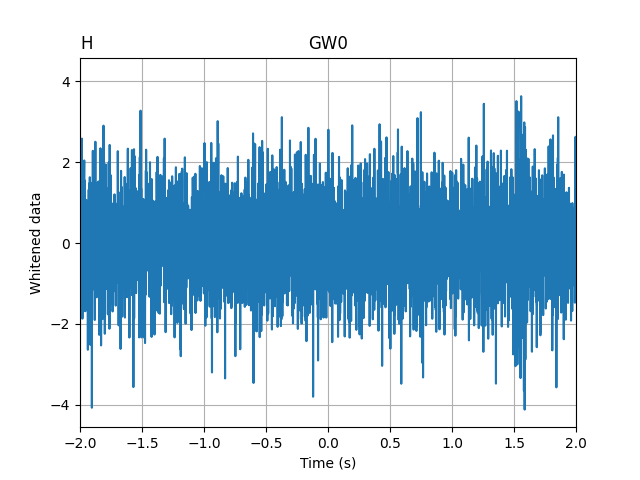

In [7]:
# The same but just one detector
i_det = 0
det_name = event_data.detector_names[i_det]
wht_strain = whitened_td[i_det]
plt.figure()
plt.plot(event_data.times - event_data.tcoarse, wht_strain)
plt.grid()
plt.title(det_name, loc='left')

plt.xlim(xlim)
plt.xlabel('Time (s)')
plt.ylabel('Whitened data')
plt.title(event_data.eventname);

We can get another crude estimate of the chirp mass as follows (inspired by https://arxiv.org/pdf/1608.01940 Sec 2)
* Estimate the frequency of the wave as a function of time
* Estimate the slope of $f^{-8/3}(t)$.
* Estimate the chirp mass
> *Note:* in the code we work assuming units of solar masses or Hertz, so actually
> \begin{align}
      \texttt{mchirp} &= \frac{\mathcal{M}}{M_\odot} \\
      \texttt{freq} &= \frac{f}{\rm Hz}
  \end{align}
> A handy conversion factor is
> $$
     \frac{G M_\odot}{c^3 \, \text{Hz}} = 4.9 \cdot 10^{-6},
  $$
> provided in LAL (LIGO-Virgo-KAGRA Algorithm Library) as `lal.MTSUN_SI`:


In [8]:
lal.MTSUN_SI

4.925490947641267e-06

### Example solution (but try yourself, many solution strategies possible!)

Find zero-crossings of the whitened data

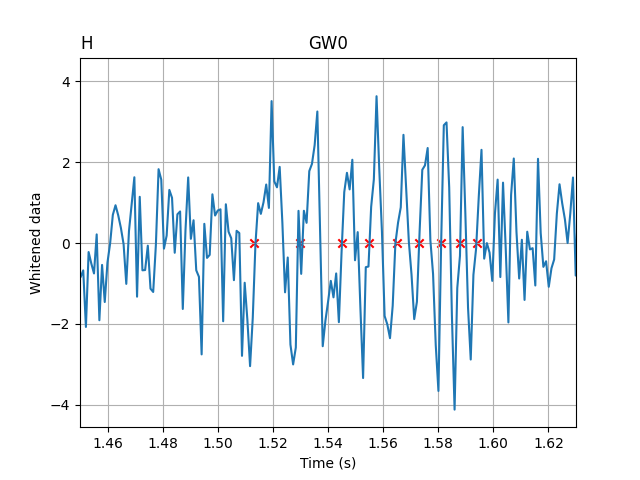

In [9]:
i_det = 0
xlim = 1.45, 1.63  # -5.15, -5.05

det_name = event_data.detector_names[i_det]
wht_strain = whitened_td[i_det]

plt.figure()
x = event_data.times - event_data.tcoarse
plt.plot(x, wht_strain)
plt.grid()
plt.title(det_name, loc='left')

plt.xlim(xlim)
plt.xlabel('Time (s)')
plt.ylabel('Whitened data')
plt.title(event_data.eventname)

# zero_crossings_idx = np.where(np.diff(np.sign(wht_strain))) # kind of iffy, will just find locations of sign change
# ascending_zero_crossings = x[zero_crossings_idx]
ascending_zero_crossings = 1.513, 1.53, 1.545, 1.555, 1.565, 1.573, 1.581, 1.588, 1.594 # *how did Javier get these?
plt.scatter(ascending_zero_crossings, [0] * len(ascending_zero_crossings), c='r', marker='x')

Find frequencies from these

In [10]:
periods = np.diff(ascending_zero_crossings)
times = np.add(ascending_zero_crossings[:-1], ascending_zero_crossings[1:]) / 2
frequencies = 1 / periods

Linear fit $f^{-8/3}$ vs $t$:

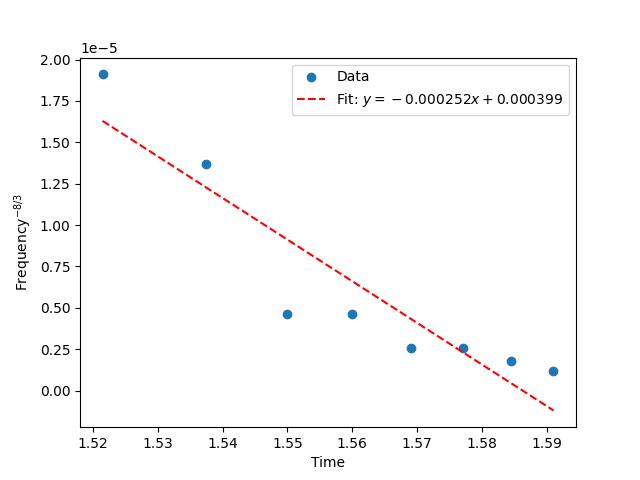

In [11]:
y = frequencies**(-8/3)
x = times

# Perform linear fit
slope, const = np.polyfit(times, y, deg=1)

# Generate fitted line for plotting
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = slope * x_fit + const

# Plot
plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x_fit, y_fit, 'r--', label=rf'Fit: $y = {slope:.3g} x + {const:.3g}$')
plt.xlabel("Time")
plt.ylabel("Frequency$^{-8/3}$")
plt.legend()
plt.show()

In [12]:
# slope == (8*np.pi)**(8/3) / 5 * (lal.MTSUN_SI * mchirp)**(5/3)
mchirp_guess = (-slope / (8*np.pi)**(8/3) * 5)**(3/5) / lal.MTSUN_SI
print(mchirp_guess)

21.238441342535648


## Find a well-fitting waveform
Armed with our guess (which normally one would get from the search pipeline...), we can now do a fast likelihood maximization to find our reference waveform:

In [13]:
approximant = 'IMRPhenomXAS'
prior_class = 'IntrinsicAlignedSpinIASPrior'

posterior = cogwheel.posterior.Posterior.from_event(
    event_data,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

Searching incoherent solution for GW0
Set intrinsic parameters, lnL = 208.4437426645836
Set time, lnL(H) = 123.3278486696809
Set sky location, lnL = 204.0378431603024
Set phase and distance, lnL = 204.0378431603024
Set mchirp_range = (19.902193304280324, 119.50782786365778)


Now we have a (crude) best-fit waveform, which is stored in `posterior.likelihood.par_dic_0`.
Only the most important parameters have been optimized and some approximations have been made, but if everything went well we should have a decent fit to the data.

In [14]:
posterior.likelihood.par_dic_0

{'d_luminosity': 763.8102300664352,
 'dec': -0.3845903901291026,
 'f_ref': 100.0,
 'iota': 2.141592653589793,
 'l1': 0.0,
 'l2': 0.0,
 'm1': 163.76335976557192,
 'm2': 11.138763723070184,
 'phi_ref': -0.4410127001543546,
 'psi': 0.0,
 'ra': 2.1354846823974754,
 's1x_n': 0.0,
 's1y_n': 0.0,
 's1z': 0.9965160723642259,
 's2x_n': 0.0,
 's2y_n': 0.0,
 's2z': 0.9965160723642259,
 't_geocenter': 1.5443665758395815}

* How does this fit compare to your initial guess? Recall $\mathcal{M} = (m_1 m_2)^{3/5} / (m_1 + m_2)^{1/5}$

We can inspect whether we have a decent fit:

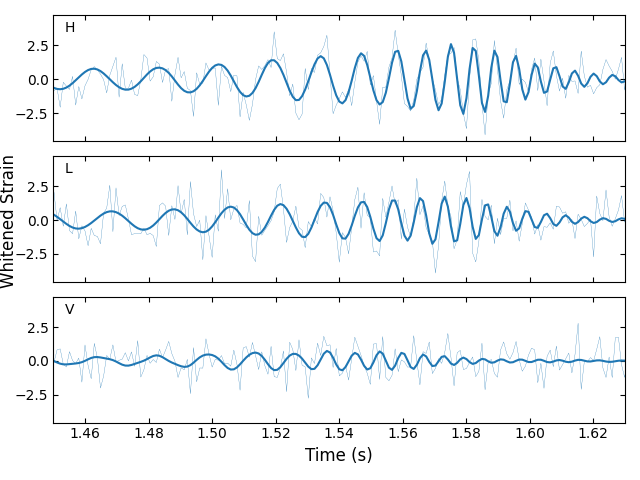

In [15]:
posterior.likelihood.plot_whitened_wf(posterior.likelihood.par_dic_0, trng=xlim);

## Sample the posterior

### `cogwheel` basics
The `posterior` object contains a `posterior.prior` and a `posterior.likelihood`. The posterior and the prior are distributions over the space of parameters.
We will use two sytems of coordinates: **sampled parameters** $\vartheta$ and **standard parameters** $\theta$.
* **Sampled parameters** are intended to remove correlations from the posterior. We express the posterior in these coordinates to ease sampling.
* **Standard parameters** are of astrophysical interest, and are understood by waveform modeling libraries (and fellow astrophysicists). The likelihood class uses standard parameters, so that we don't need to redefine it if we want to switch sampling coordinates.

The transformations between them are provided by the `posterior.prior` object:
* $\texttt{prior.sampled\_params} = \vartheta$ names
* $\texttt{prior.standard\_params} = \theta$ names
* $\texttt{prior.transform} : \vartheta \to \theta$
* $\texttt{prior.inverse\_transform} : \theta \to \vartheta$

The methods `posterior.lnposterior`, `posterior.prior.lnprior` and `posterior.likelihood.lnlike` are related by:
$$
    \mathcal{P}(\vartheta \mid d) = \pi(\vartheta) \mathcal{L}(d \mid \theta).
$$

### Extrinsic-parameter marginalization

Extrinsic parameters have a known functional form in the prior and likelihood, which allows to marginalize them semianalytically.
This reduces the dimensionality of the parameter space and speeds up sampling. To use this feature, we simply choose a prior for the intrinsic parameters (`'IntrinsicAlignedSpinIASPrior'`), and `cogwheel` understands that we want to use a marginalized likelihood $\overline{\mathcal{L}}(\theta_\mathrm{int} \mid d)$.

* Think of all the parameters that characterize a GW source. What do you expect the standard parameters to be in this case?
* Check in the `posterior.prior` object: what are the sampled parameters and standard parameters? Does this make sense?

In [16]:
sampler = cogwheel.sampling.Nautilus(posterior)
# These trade off quality and speed:
sampler.run_kwargs['n_live'] = 1000
sampler.run_kwargs['n_eff'] = 2000

In [17]:
%%time
rundir = sampler.get_rundir(parentdir='pe_runs')
sampler.run(rundir)  # Will take a bit

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30800    | N/A    | 8220  | +157.67  
CPU times: user 29min 56s, sys: 13min 12s, total: 43min 9s
Wall time: 6min 53s


Let's load the samples. They are in the form of a dataframe (table) where the columns are parameters of the source, and the rows are samples from the posterior.

> **Note:** Some samplers like [nautilus](https://nautilus-sampler.readthedocs.io/en/latest/) produce *weighted* posterior samples. Notice that the dataframe contains a column `"weights"`. For example, to make a histogram you would do
> ```python
> plt.hist(samples['m1'], weights=samples['weights'])
> ```

In [18]:
samples = pd.read_feather(rundir/'samples.feather')
samples

,mchirp,lnq,chieff,cumchidiff,weights,m1,m2,s1z,s2z,l1,...,phi_ref,psi,iota,t_geocenter,lnl_marginalized,lnl,h_h,n_effective,n_qmc,ra
0,118.722969,-2.160494,-0.209924,0.468887,6.003886e-76,443.593300,51.132186,-0.241295,0.062227,0.0,...,2.239119,0.113333,1.846240,1.255213,-2.136519,0.594184,0.083931,21.397454,4096,5.123037
1,89.389400,-2.192990,-0.529660,0.207861,2.184960e-76,340.342725,37.976328,-0.653956,0.584278,0.0,...,0.790092,1.756637,1.563312,1.238597,-2.868713,0.657148,0.100378,20.052106,2048,3.930128
2,112.923548,-2.170989,-0.242086,0.084722,3.415503e-76,424.498067,48.420268,-0.364436,0.830556,0.0,...,0.427721,3.117087,0.532193,1.241576,-2.652186,-0.272265,0.198629,24.833753,2048,0.002353
3,116.168606,-2.076872,0.204771,0.681437,8.174127e-76,413.550398,51.826819,0.275909,-0.362874,0.0,...,3.894619,0.141963,1.059831,1.246711,-1.793067,2.562821,1.074703,58.773015,2048,3.372051
4,110.468509,-0.853983,0.011692,0.787218,3.464579e-71,197.958025,84.273899,0.261215,-0.574435,0.0,...,3.735228,3.119126,0.832417,1.483622,9.061724,19.285655,30.380039,4.550270,2048,0.618859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30795,29.398878,-2.785479,0.913389,0.907489,8.058785e-06,158.256685,9.764360,0.991493,-0.352493,0.0,...,5.466512,2.350181,2.691209,1.545109,179.079967,207.930065,409.725688,51.474230,2048,2.156717
30796,29.485595,-2.772086,0.920046,0.903646,8.524727e-06,157.477765,9.847309,0.991814,-0.227668,0.0,...,6.138628,2.967845,2.391196,1.544266,179.135595,207.201392,383.546693,53.483302,2048,2.192289
30797,29.029068,-2.785603,0.903995,0.880912,8.881035e-06,156.277304,9.641044,0.987862,-0.455449,0.0,...,2.546156,2.739293,2.698472,1.544356,179.189759,206.838173,484.818206,88.537833,4096,2.148288
30798,28.757574,-2.796703,0.889385,0.902072,1.010424e-05,155.830227,9.507345,0.988507,-0.735275,0.0,...,3.316606,0.162024,2.777470,1.545175,179.326230,204.939547,347.755116,59.447504,2048,2.142325


In [19]:
list(samples)

['mchirp',
 'lnq',
 'chieff',
 'cumchidiff',
 'weights',
 'm1',
 'm2',
 's1z',
 's2z',
 'l1',
 'l2',
 'f_ref',
 'd_luminosity',
 'dec',
 'lon',
 'phi_ref',
 'psi',
 'iota',
 't_geocenter',
 'lnl_marginalized',
 'lnl',
 'h_h',
 'n_effective',
 'n_qmc',
 'ra']

DataFrames allow to easily add columns. Let's add some derived quantities:

In [23]:
def add_derived_quantities(samples):
    """
    Add columns inplace to a dataframe of samples.

    Includes redshift, mtot, m1_source, m2_source, mtot_source, chieff, q.
    """
    samples['redshift'] = cogwheel.cosmology.z_of_d_luminosity(samples['d_luminosity'])

    samples['mtot'] = samples['m1'] + samples['m2']

    for mass_key in 'm1', 'm2', 'mtot':
        samples[f'{mass_key}_source'] = samples[mass_key] / (1 + samples['redshift'])

    samples['chieff'] = cogwheel.gw_utils.chieff(**samples[['m1', 'm2', 's1z', 's2z']])

    samples['q'] = samples['m2'] / samples['m1']


add_derived_quantities(samples)

In [24]:
plot_params = [
    # 'mchirp',
    # 'lnq',
    # 'chieff',
    # 'cumchidiff',
    # 'weights',
    'm1',
    'm2',
    's1z',
    's2z',
    # 'l1',
    # 'l2',
    # 'f_ref',
    'd_luminosity',
    'ra',
    'dec',
    # 'lon',
    'phi_ref',
    'psi',
    'iota',
    't_geocenter',
    # 'lnl_marginalized',
    'lnl',
    # 'h_h',
    # 'n_effective',
    # 'n_qmc',
]

If you haven't before, it is good to spend some time staring at a corner plot of the posterior.

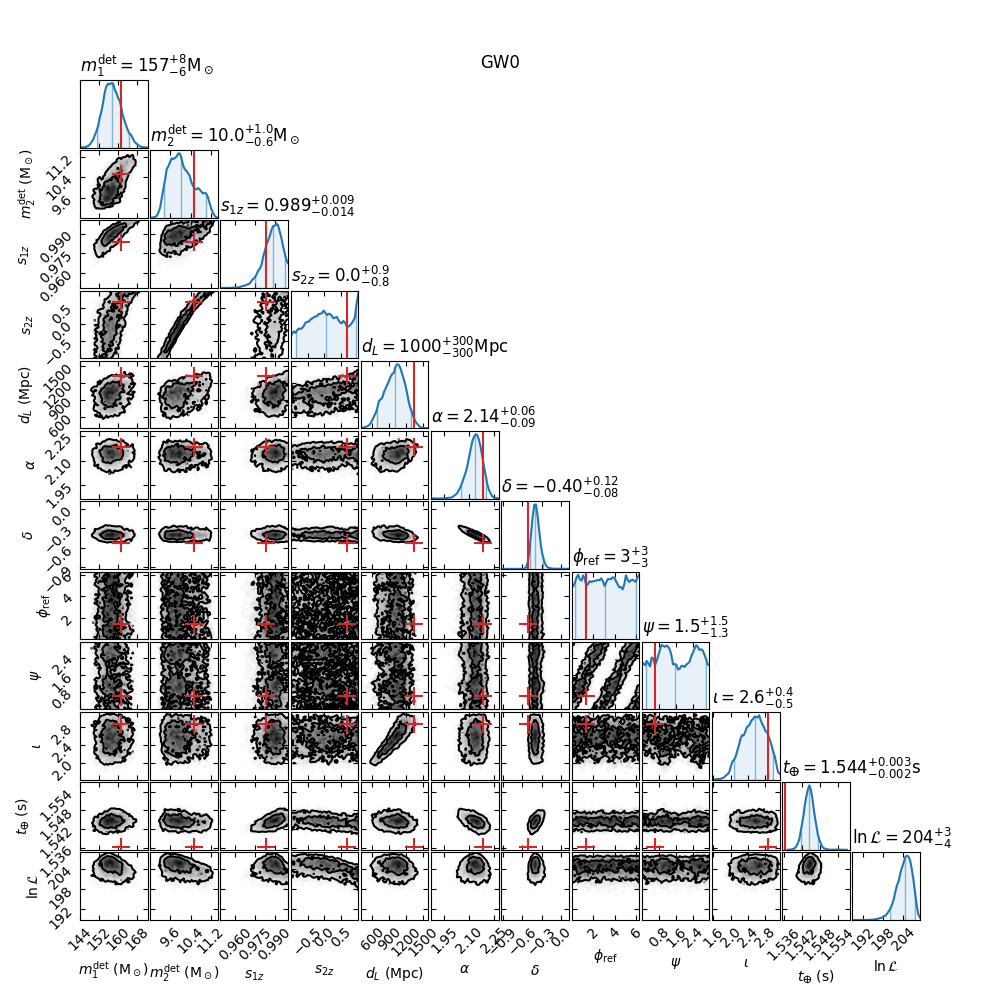

In [25]:
# Note: cogwheel.gw_plotting.CornerPlot understands the weights automatically
corner_plot = cogwheel.gw_plotting.CornerPlot(
    samples, params=plot_params, tail_probability=1e-4
)
corner_plot.plot(title=event_data.eventname)

# Let's also reveal the true (injected) value
corner_plot.scatter_points(event_data.injection['par_dic'], colors=['C3'], s=150,
                           zorder=2, marker='+', adjust_lims=True);

A corner plot shows 1d histograms in the diagonal, and 2d histograms of every parameter against every other off-diagonal.

* What parameters are correlated? Can you think of reasons why these correlations arise?
* Look at the log likelihood-ratio of the samples. Can you estimate the SNR of the signal?
* Are any parameters discrepant with the injection? Is this expected?

One subtlety is that the injection was made with the waveform model (approximant) `IMRPhenomXODE`, and the parameter inference with `IMRPhenomXAS` (which parameters should have the same physical meaning in both cases? which not?).


## Extra


`IMRPhenomXAS` only describes the quadrupolar radiation and assumes the spins are aligned.
This helped simplify some computations and reduced the dimensionality of the parameter space, but we can get more accurate results.

Let's now use `IMRPhenomXODE`, a more refined model that includes precession and higher-order harmonics, to do the inference.

In [ ]:
posterior_xode = cogwheel.posterior.Posterior.from_event(
    event_data,
    mchirp_guess,
    approximant='IMRPhenomXODE',
    prior_class='IntrinsicIASPrior',
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

* Note that we use a different prior class because now we have generic spins. Which are the sampled and standard parameters?

In [ ]:
# Check that the fit makes sense
posterior_xode.likelihood.plot_whitened_wf(posterior_xode.likelihood.par_dic_0)
plt.xlim(xlim);

In [ ]:
sampler_xode = cogwheel.sampling.Nautilus(posterior_xode)
sampler_xode.run_kwargs['n_live'] = 1000
sampler_xode.run_kwargs['n_eff'] = 2000

In [ ]:
rundir_xode = sampler_xode.get_rundir(parentdir='pe_runs')

In [ ]:
%%time
sampler_xode.run(rundir_xode)  # Will take a while

In [ ]:
samples_xode = pd.read_feather(rundir_xode/'samples.feather')
add_derived_quantities(samples_xode)

In [ ]:
corner_plot = cogwheel.gw_plotting.CornerPlot(samples_xode, params=plot_params, tail_probability=1e-4)
corner_plot.plot(title=event_data.eventname)

corner_plot.scatter_points(event_data.injection['par_dic'], colors=['C3'], s=150,
                           zorder=2, marker='+', adjust_lims=True);

Let's compare the two runs:

In [ ]:
multi_corner_plot = cogwheel.gw_plotting.MultiCornerPlot(
    {'IMRPhenomXAS': samples,
     'IMRPhenomXODE': samples_xode}
    , params=plot_params, tail_probability=1e-4)
multi_corner_plot.plot(title=event_data.eventname)

multi_corner_plot.scatter_points(event_data.injection['par_dic'], colors=['k'], s=150,
                                 zorder=2, marker='+', adjust_lims=True);

The difference between these two runs is that IMRPhenomXODE includes the effects of misaligned spins (precession) and harmonic modes $(\ell, |m|)$ other than the quadrupole $(2, 2)$.
* Which parameters are affected the most, and the least? Does this make sense to you?
* Which model best fits the data?

In [ ]:
sampler_xode.load_evidence()

In [ ]:
sampler.load_evidence()

In [ ]:
best_fit = samples_xode.iloc[samples_xode['lnl'].idxmax()]
fig = sampler_xode.posterior.likelihood.plot_whitened_wf(best_fit, trng=(-.4, .2))
fig.suptitle(event_data.eventname)
plt.xlim(xlim)

## Extra 2

Now you can infer the parameters of a real event!

This is how you would obtain the `EventData` object in `cogwheel`:

```python
eventname = 'GW190412'
filenames, detector_names, tgps = cogwheel.data.download_timeseries(eventname)
event_data = cogwheel.data.EventData.from_timeseries(
    filenames, eventname, detector_names, tgps)
```

GW190412 [https://arxiv.org/pdf/2004.08342] is a real-world example of the effects of adding higher modes on parameter inference. Can you reproduce the conclusion of Fig. 4 of that paper?

In [3]:
eventname = 'GW150914' #231123_135430'
filenames, detector_names, tgps = cogwheel.data.download_timeseries(eventname)
event_data = cogwheel.data.EventData.from_timeseries(filenames, eventname, detector_names, tgps)

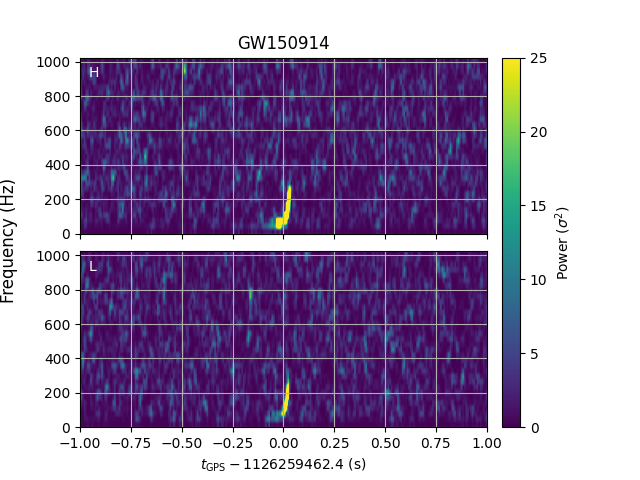

In [4]:
# let's plot the data
xlim = (-1, 1)
event_data.specgram(xlim=xlim, vmax=25)

In [7]:
# guess the merger time
t_merger_guess = 0.02

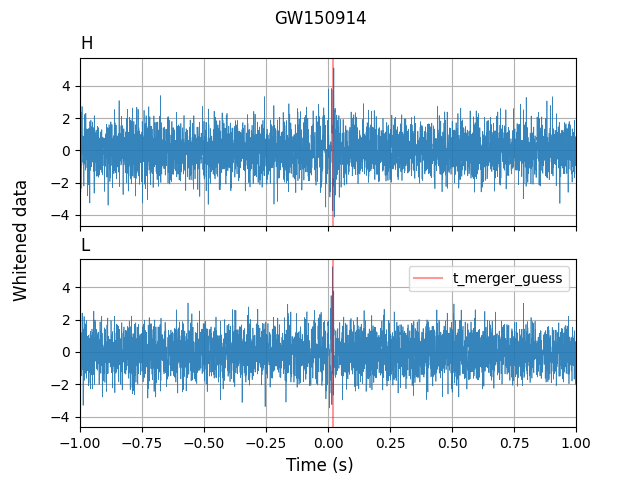

In [8]:
# check out the whitened data:
whitened_td = event_data.get_whitened_td()

fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for det_name, ax, wht_strain in zip(event_data.detector_names, axs, whitened_td):
    ax.plot(event_data.times - event_data.tcoarse, wht_strain, lw=0.5, alpha=0.9)
    ax.grid()
    ax.set_title(det_name, loc='left')
    ax.axvline(t_merger_guess, c='r', alpha=0.4, label='t_merger_guess')

ax.set_xlim(xlim)
fig.supxlabel('Time (s)')
fig.supylabel('Whitened data')
fig.suptitle(event_data.eventname);
ax.legend()

Text(0.5, 1.0, 'GW150914')

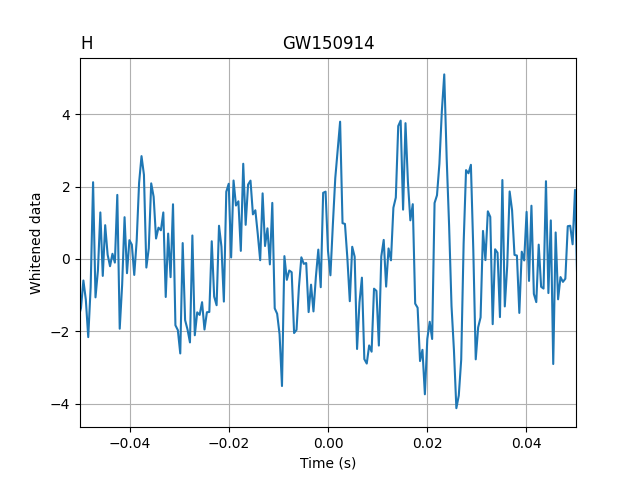

In [11]:
# estimate the chirp mass:
i_det = 0
xlim = -0.05, 0.05

det_name = event_data.detector_names[i_det]
wht_strain = whitened_td[i_det]

plt.figure()
x = event_data.times - event_data.tcoarse
plt.plot(x, wht_strain)
plt.grid()
plt.title(det_name, loc='left')

plt.xlim(xlim)
plt.xlabel('Time (s)')
plt.ylabel('Whitened data')
plt.title(event_data.eventname)

# ascending_zero_crossings = -.0176, -.0031, .0117, .0253, .0356, .0462, 
# plt.scatter(ascending_zero_crossings, [0] * len(ascending_zero_crossings), c='r', marker='x')

In [67]:
mchirp_guess = 10

In [68]:
approximant = 'IMRPhenomXAS'
prior_class = 'IntrinsicAlignedSpinIASPrior'

posterior = cogwheel.posterior.Posterior.from_event(
    event_data,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

Searching incoherent solution for GW231123_135430
Set intrinsic parameters, lnL = 72.30357893880311
Set time, lnL(L) = 40.266376649888244
Set sky location, lnL = 58.510059444295194
Set phase and distance, lnL = 58.51005944429519
Set mchirp_range = (8.492329139324463, 10.231675630541623)


In [65]:
posterior.likelihood.par_dic_0

{'d_luminosity': 2650.3492545793324,
 'dec': 0.7669551638862849,
 'f_ref': 100.0,
 'iota': 1.0,
 'l1': 0.0,
 'l2': 0.0,
 'm1': 219.32838215179584,
 'm2': 143.59119352646186,
 'phi_ref': 0.9456437424138676,
 'psi': 0.0,
 'ra': 4.5270165582061495,
 's1x_n': 0.0,
 's1y_n': 0.0,
 's1z': 0.8407536803350835,
 's2x_n': 0.0,
 's2y_n': 0.0,
 's2z': 0.8407536803350835,
 't_geocenter': -0.09555076915759474}

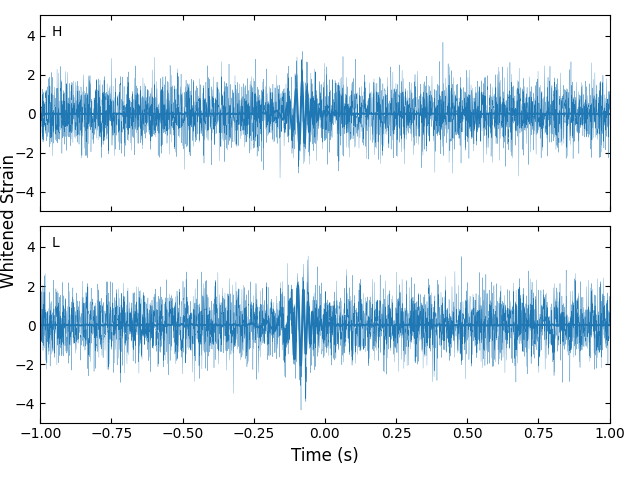

In [66]:
posterior.likelihood.plot_whitened_wf(posterior.likelihood.par_dic_0, trng=xlim);